# SPI walltime benchmark — initial inspection

Loads every `data/benchmark/*/*.json` produced by `scripts/benchmark_spis.py`, filters to cells that actually completed (`n_spis > 0`, no error), and plots the distribution of per-SPI walltimes aggregated across all available (M, T) cells.

Per-SPI wall-time is `results[*].timings[spi_name].mean` (with `--repeats 1` this equals the single observation).

In [75]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

REPO_ROOT = Path.cwd().parents[1] if Path.cwd().name == 'benchmark' else Path.cwd()
BENCH_DIR = REPO_ROOT / 'data' / 'benchmark'

rows = []
families = {}  # spi_name -> family (from any JSON's spi_metadata)
skipped = []
for f in sorted(BENCH_DIR.glob('*/*.json')):
    if f.parent.name.startswith('_'):
        continue  # archived failed runs
    with open(f) as fh:
        doc = json.load(fh)
    for spi, meta in (doc.get('spi_metadata') or {}).items():
        families.setdefault(spi, meta.get('family', 'unknown'))
    for r in doc['results']:
        if r.get('error') is not None or r.get('n_spis', 0) == 0:
            skipped.append((str(f.relative_to(REPO_ROOT)), r.get('M'), r.get('T'), r.get('error')))
            continue
        for spi, t in (r.get('timings') or {}).items():
            rows.append({
                'source': f.parent.name,
                'M': r['M'],
                'T': r['T'],
                'spi': spi,
                'family': families.get(spi, 'unknown'),
                'walltime_s': float(t['mean']),
            })

df = pd.DataFrame(rows)
if len(df):
    print(f'Loaded {len(df):,} (spi, cell) rows  |  {df[["M","T"]].drop_duplicates().shape[0]} cells  |  {df["spi"].nunique()} unique SPIs')
    print('Families:', df.groupby("family")["spi"].nunique().to_dict())
else:
    print('No valid rows — rsync fresh results from cluster.')
if skipped:
    print(f'Skipped {len(skipped)} errored/empty result(s).')
df.head()

Loaded 7,216 (spi, cell) rows  |  22 cells  |  328 unique SPIs
Families: {'basic': 84, 'causal': 12, 'distance': 44, 'infotheory': 43, 'misc': 25, 'spectral': 114, 'wavelet': 6}


,source,M,T,spi,family,walltime_s
0,sweep,2,100,cov_EmpiricalCovariance,basic,0.060388
1,sweep,2,100,cov_EllipticEnvelope,basic,0.047160
2,sweep,2,100,cov_GraphicalLasso,basic,0.001107
3,sweep,2,100,cov_GraphicalLassoCV,basic,0.047756
4,sweep,2,100,cov_LedoitWolf,basic,0.000656


In [76]:
# Which cells are present in the current snapshot?
if len(df):
    cell_summary = (
        df.groupby(['source', 'M', 'T'])
          .agg(n_spis=('spi', 'nunique'), total_wall_s=('walltime_s', 'sum'))
          .reset_index()
          .sort_values(['source', 'M', 'T'])
    )
    display(cell_summary)
else:
    print('(no data yet)')

,source,M,T,n_spis,total_wall_s
0,sweep,2,100,328,122.570259
1,sweep,2,200,328,141.792546
2,sweep,2,400,328,135.952220
3,sweep,2,800,328,121.826411
4,sweep,2,1600,328,201.909130
5,sweep,2,3200,328,680.509476
6,sweep,4,100,328,419.483110
7,sweep,4,200,328,425.076974
8,sweep,4,400,328,454.163104
9,sweep,4,800,328,541.240588


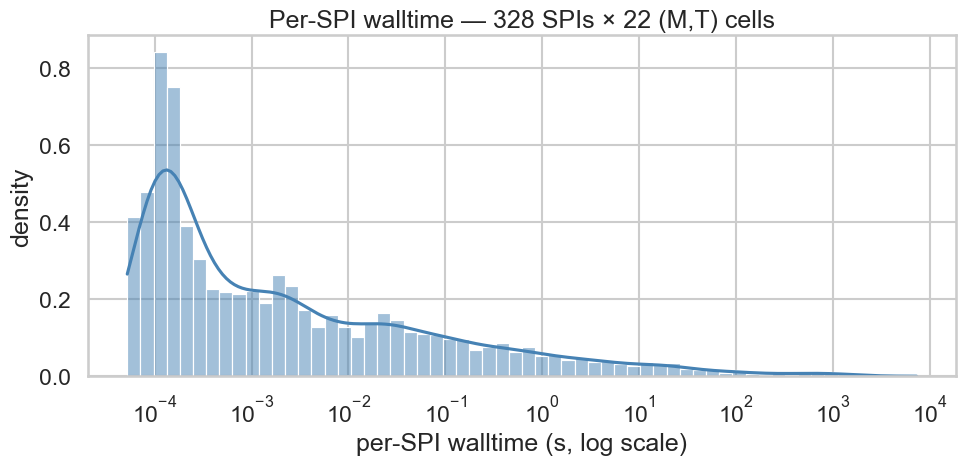

In [77]:
# Density of SPIs (y) vs per-SPI walltime (x), aggregated across every (M, T)
# cell in the current snapshot. Log-x because SPI timings span multiple
# orders of magnitude (linear SPIs ~1e-4 s, DTW/kraskov variants seconds).
if len(df):
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(
        data=df, x='walltime_s',
        stat='density', bins=60,
        log_scale=(True, False),
        kde=True, color='steelblue', ax=ax,
    )
    ax.set_xlabel('per-SPI walltime (s, log scale)')
    ax.set_ylabel('density')
    ax.set_title(
        f'Per-SPI walltime — {df["spi"].nunique()} SPIs × '
        f'{df[["M","T"]].drop_duplicates().shape[0]} (M,T) cells'
    )
    plt.tight_layout()
    plt.show()
else:
    print('(no data yet)')

In [78]:
# Interactive strip plot — one dot per (SPI, cell) observation, hover shows
# which SPI, which (M,T), and the wall-time in seconds. Colored by family
# because that's the most informative axis given the long tails (DTW variants
# dominate "distance", kraskov_* dominate "infotheory", etc.).
# Open this cell's output and hover any dot to identify the SPI.
import plotly.express as px

if len(df):
    fig = px.strip(
        df.sort_values("family"),
        x="walltime_s",
        y="family",
        color="family",
        log_x=True,
        hover_data={
            "spi": True, "M": True, "T": True,
            "walltime_s": ":.4f", "family": False,
        },
        stripmode="overlay",
        height=520,
    )
    fig.update_traces(jitter=0.35, marker={"size": 6, "opacity": 0.75})
    fig.update_layout(
        xaxis_title="per-SPI walltime (s, log scale)",
        yaxis_title="family",
        title=f'Per-SPI walltime by family — {df["spi"].nunique()} SPIs × '
              f'{df[["M","T"]].drop_duplicates().shape[0]} (M,T) cells',
        legend_title_text="family",
        margin={"l": 100, "r": 20, "t": 60, "b": 50},
    )
    fig.show()
else:
    print('(no data yet)')

In [79]:
# Per-cell interactive view: each frame is one (M, T) cell from the sweep.
# Slider lets you scrub through cells; hover a dot to identify the SPI.
# Same log-x and family coloring as the pooled plot above, so pooled vs
# per-cell views are directly comparable.
if len(df):
    df_cell = df.assign(cell=df['M'].astype(str).radd('M=') + ', T=' + df['T'].astype(str))
    cell_order = sorted(df_cell['cell'].unique(),
                        key=lambda s: (int(s.split(',')[0][2:]), int(s.split('T=')[1])))
    family_order = sorted(df_cell['family'].unique())

    # Pad a dummy row for any cell missing a family, otherwise animation
    # frames silently drop that family from the y-axis.
    fill = []
    for cell in cell_order:
        present = set(df_cell.loc[df_cell['cell'] == cell, 'family'])
        for fam in family_order:
            if fam not in present:
                fill.append({'cell': cell, 'family': fam, 'spi': '',
                             'walltime_s': float('nan'), 'M': None, 'T': None})
    if fill:
        df_cell = pd.concat([df_cell, pd.DataFrame(fill)], ignore_index=True)

    fig = px.strip(
        df_cell,
        x='walltime_s', y='family', color='family',
        animation_frame='cell',
        category_orders={'cell': cell_order, 'family': family_order},
        log_x=True,
        hover_data={
            'spi': True, 'M': True, 'T': True,
            'walltime_s': ':.4f', 'family': False, 'cell': False,
        },
        stripmode='overlay',
        height=520,
        range_x=[df_cell['walltime_s'].min() * 0.5,
                 df_cell['walltime_s'].max() * 2],
    )
    fig.update_traces(jitter=0.35, marker={'size': 6, 'opacity': 0.75})
    fig.update_layout(
        xaxis_title='per-SPI walltime (s, log scale)',
        yaxis_title='family',
        title='Per-SPI walltime per (M, T) cell — use slider / play button',
        legend_title_text='family',
        margin={'l': 100, 'r': 20, 't': 60, 'b': 80},
    )
    fig.show()
else:
    print('(no data yet)')

In [80]:
# Per-cell per-family raincloud view: each frame is one (M, T) cell, with
# one half violin plus jittered SPI points for each family row.
import plotly.express as px

df_pos = df.loc[df['walltime_s'] > 0].copy()

if len(df_pos):
    df_cell = df_pos.assign(
        cell=df_pos['M'].astype(str).radd('M=') + ', T=' + df_pos['T'].astype(str),
        log_walltime_s=np.log10(df_pos['walltime_s']),
    )
    cell_order = sorted(df_cell['cell'].unique(),
                        key=lambda s: (int(s.split(',')[0][2:]), int(s.split('T=')[1])))
    family_order = sorted(df_cell['family'].unique())

    fill = []
    for cell in cell_order:
        present = set(df_cell.loc[df_cell['cell'] == cell, 'family'])
        for fam in family_order:
            if fam not in present:
                fill.append({'cell': cell, 'family': fam, 'spi': '',
                             'walltime_s': float('nan'), 'log_walltime_s': float('nan'),
                             'M': None, 'T': None})
    if fill:
        df_cell = pd.concat([df_cell, pd.DataFrame(fill)], ignore_index=True)

    exp_min = int(np.floor(df_cell['log_walltime_s'].min()))
    exp_max = int(np.ceil(df_cell['log_walltime_s'].max()))
    tickvals = list(range(exp_min, exp_max + 1))
    ticktext = [f'{10**exp:g}' for exp in tickvals]

    fig = px.violin(
        df_cell,
        x='log_walltime_s', y='family', color='family',
        animation_frame='cell',
        category_orders={'cell': cell_order, 'family': family_order},
        hover_data={
            'spi': True, 'M': True, 'T': True,
            'walltime_s': ':.4f', 'family': False, 'cell': False,
            'log_walltime_s': False,
        },
        points='all',
        height=1000,
        range_x=[df_cell['log_walltime_s'].min() - 0.2,
                 df_cell['log_walltime_s'].max() + 0.2],
    )

    style = {
        'side': 'positive',
        'pointpos': -0.35,
        'jitter': 0.22,
        'width': 0.55,
        'meanline_visible': False,
        'box_visible': False,
        'marker': {'size': 6, 'opacity': 0.72},
        'opacity': 0.72,
    }
    for trace in fig.data:
        trace.update(**style)
    for frame in fig.frames:
        for trace in frame.data:
            trace.update(**style)

    fig.update_layout(
        xaxis={
            'title': 'per-SPI walltime (s, log scale)',
            'tickmode': 'array',
            'tickvals': tickvals,
            'ticktext': ticktext,
        },
        yaxis_title='family',
        title='Per-family raincloud walltime per (M, T) cell - use slider / play button',
        legend_title_text='family',
        margin={'l': 100, 'r': 20, 't': 60, 'b': 80},
    )
    fig.show()
else:
    print('(no data yet)')


In [81]:
# Per-cell pooled raincloud view: one half violin for the full SPI
# distribution, plus family-colored SPI dots on the opposite side.
import plotly.express as px
import plotly.graph_objects as go

df_pos = df.loc[df['walltime_s'] > 0].copy()

if len(df_pos):
    df_cell = df_pos.assign(
        cell=df_pos['M'].astype(str).radd('M=') + ', T=' + df_pos['T'].astype(str),
        log_walltime_s=np.log10(df_pos['walltime_s']),
    )
    cell_order = sorted(df_cell['cell'].unique(),
                        key=lambda s: (int(s.split(',')[0][2:]), int(s.split('T=')[1])))
    family_order = sorted(df_cell['family'].unique())
    colors = px.colors.qualitative.Plotly
    family_colors = {fam: colors[i % len(colors)] for i, fam in enumerate(family_order)}

    log_min = df_cell['log_walltime_s'].min() - 0.2
    log_max = df_cell['log_walltime_s'].max() + 0.2
    exp_min = int(np.floor(df_cell['log_walltime_s'].min()))
    exp_max = int(np.ceil(df_cell['log_walltime_s'].max()))
    tickvals = list(range(exp_min, exp_max + 1))
    ticktext = [f'{10**exp:g}' for exp in tickvals]

    def make_traces(cell, cell_idx):
        cell_df = df_cell.loc[df_cell['cell'] == cell].sort_values('log_walltime_s')
        traces = [
            go.Violin(
                x=cell_df['log_walltime_s'],
                y=np.zeros(len(cell_df)),
                orientation='h',
                side='positive',
                width=0.8,
                spanmode='soft',
                bandwidth=0.18,
                line_color='rgba(90, 90, 90, 0.75)',
                fillcolor='rgba(150, 150, 150, 0.35)',
                points=False,
                showlegend=False,
                hoverinfo='skip',
                name='distribution',
            )
        ]
        for fam_idx, fam in enumerate(family_order):
            fam_df = cell_df.loc[cell_df['family'] == fam]
            rng = np.random.default_rng(cell_idx * 100 + fam_idx)
            traces.append(
                go.Scatter(
                    x=fam_df['log_walltime_s'],
                    y=-0.4 + 0.25 * rng.random(len(fam_df)),
                    opacity=0.65,
                    mode='markers',
                    name=fam,
                    legendgroup=fam,
                    showlegend=True,
                    marker={'color': family_colors[fam], 'size': 7, 'opacity': 0.78},
                    customdata=fam_df[['spi', 'family', 'M', 'T', 'walltime_s']].to_numpy(),
                    hovertemplate='spi=%{customdata[0]}<br>'
                                  'family=%{customdata[1]}<br>'
                                  'M=%{customdata[2]}<br>'
                                  'T=%{customdata[3]}<br>'
                                  'walltime_s=%{customdata[4]:.4f}<extra></extra>',
                )
            )
        return traces

    fig = go.Figure(
        data=make_traces(cell_order[0], 0),
        frames=[go.Frame(name=cell, data=make_traces(cell, i))
                for i, cell in enumerate(cell_order)],
    )
    fig.update_layout(
        title='Per-SPI walltime per (M, T) cell - pooled raincloud; use slider / play button',
        xaxis={
            'title': 'per-SPI walltime (s, log scale)',
            'range': [log_min, log_max],
            'tickmode': 'array',
            'tickvals': tickvals,
            'ticktext': ticktext,
        },
        yaxis={
            'range': [-0.7, 0.7],
            'showgrid': False,
            'zeroline': False,
            'showticklabels': False,
            'title': '',
        },
        legend={
            'title': {'text': 'family'},
            'x': 1.02,
            'y': 1.0,
            'xanchor': 'left',
            'yanchor': 'top',
        },
        hovermode='closest',
        margin={'l': 40, 'r': 150, 't': 60, 'b': 80},
        updatemenus=[{
            'type': 'buttons',
            'direction': 'left',
            'x': 0.0,
            'y': 1.12,
            'showactive': False,
            'buttons': [
                {
                    'label': 'Play',
                    'method': 'animate',
                    'args': [None, {
                        'frame': {'duration': 500, 'redraw': True},
                        'fromcurrent': True,
                        'transition': {'duration': 0},
                    }],
                },
                {
                    'label': 'Pause',
                    'method': 'animate',
                    'args': [[None], {
                        'frame': {'duration': 0, 'redraw': False},
                        'mode': 'immediate',
                        'transition': {'duration': 0},
                    }],
                },
            ],
        }],
        sliders=[{
            'active': 0,
            'x': 0.0,
            'y': -0.08,
            'len': 0.95,
            'currentvalue': {'prefix': 'cell: '},
            'steps': [
                {
                    'label': cell,
                    'method': 'animate',
                    'args': [[cell], {
                        'frame': {'duration': 0, 'redraw': True},
                        'mode': 'immediate',
                        'transition': {'duration': 0},
                    }],
                }
                for cell in cell_order
            ],
        }],
        height=520,
    )
    fig.show()
else:
    print('(no data yet)')


In [82]:
# Per-SPI walltime table, aggregated across all cells currently present.
# Sorted slowest first — top rows are the candidates to drop/split first
# if you're trying to trim total calculator time.
if len(df):
    spi_table = (
        df.groupby('spi')['walltime_s']
          .agg(n_cells='count', mean='mean', median='median', std='std', min='min', max='max')
          .sort_values('mean', ascending=False)
          .round(4)
    )
    pd.set_option('display.max_rows', 50)
    display(spi_table)
else:
    print('(no data yet)')

,n_cells,mean,median,std,min,max
spi,,,,,,
hhg,22,504.4898,12.5551,1571.7439,0.3023,7330.5387
ccm_E-10_mean,22,478.5299,236.0878,496.9244,21.0859,1712.6362
ccm_E-None_mean,22,474.6769,236.2075,479.3654,20.8863,1539.3921
ccm_E-1_mean,22,362.5905,123.4663,373.7767,18.8008,1121.7959
gpfit_RBF,22,152.8709,14.0119,377.5888,0.0549,1722.8776
...,...,...,...,...,...,...
prec-sq_ShrunkCovariance,22,0.0001,0.0001,0.0000,0.0001,0.0001
prec_LedoitWolf,22,0.0001,0.0001,0.0000,0.0001,0.0001
prec_GraphicalLasso,22,0.0001,0.0001,0.0000,0.0001,0.0001


In [83]:
# Thresholded slow-SPI analysis for two cells of interest.
# Summary table first, then the actual SPI lists (>=1s) with threshold flags.
focus_cells = [(8, 3200), (16, 800)]
thresholds_s = [1, 3, 5, 10]

if len(df):
    cell_order = [f'M={M}, T={T}' for M, T in focus_cells]
    df_focus = (
        df.assign(cell=df['M'].astype(str).radd('M=') + ', T=' + df['T'].astype(str))
          .loc[lambda d: d['cell'].isin(cell_order), ['cell', 'M', 'T', 'spi', 'family', 'walltime_s']]
          .copy()
    )

    if len(df_focus):
        df_focus['cell'] = pd.Categorical(df_focus['cell'], categories=cell_order, ordered=True)

        summary_rows = []
        for cell_label in cell_order:
            cell_df = df_focus.loc[df_focus['cell'] == cell_label]
            total_spis = cell_df['spi'].nunique()
            for thr in thresholds_s:
                slow = cell_df.loc[cell_df['walltime_s'] >= thr]
                summary_rows.append({
                    'cell': cell_label,
                    'threshold': f'>={thr}s',
                    'total_spis': total_spis,
                    'n_spis': slow['spi'].nunique(),
                    'share_spis_pct': 100 * slow['spi'].nunique() / total_spis if total_spis else np.nan,
                    'n_families': slow['family'].nunique(),
                    'min_s': slow['walltime_s'].min(),
                    'median_s': slow['walltime_s'].median(),
                    'mean_s': slow['walltime_s'].mean(),
                    'max_s': slow['walltime_s'].max(),
                })

        summary_table = pd.DataFrame(summary_rows).round({
            'share_spis_pct': 1,
            'min_s': 4,
            'median_s': 4,
            'mean_s': 4,
            'max_s': 4,
        })
        display(summary_table)

        pd.set_option('display.max_rows', 200)
        for cell_label in cell_order:
            print(f'\n{cell_label} slow SPIs (>=1s)')
            detail = (
                df_focus.loc[df_focus['cell'] == cell_label]
                  .loc[lambda d: d['walltime_s'] >= thresholds_s[0]]
                  .sort_values('walltime_s', ascending=False)
                  .copy()
            )
            for thr in thresholds_s:
                detail[f'>={thr}s'] = detail['walltime_s'] >= thr
            detail = detail[['spi', 'family', 'walltime_s'] + [f'>={thr}s' for thr in thresholds_s]]
            display(detail.round({'walltime_s': 4}).reset_index(drop=True))
    else:
        print('(requested cells not present in current snapshot)')
else:
    print('(no data yet)')


,cell,threshold,total_spis,n_spis,share_spis_pct,n_families,min_s,median_s,mean_s,max_s
0,"M=8, T=3200",>=1s,328,59,18.0,6,1.3014,15.5476,260.2451,7330.5387
1,"M=8, T=3200",>=3s,328,46,14.0,6,3.0288,26.5012,333.3199,7330.5387
2,"M=8, T=3200",>=5s,328,39,11.9,6,5.1799,33.6658,392.4612,7330.5387
3,"M=8, T=3200",>=10s,328,36,11.0,6,10.2855,35.9267,424.6211,7330.5387
4,"M=16, T=800",>=1s,328,53,16.2,6,1.0631,8.2183,124.3658,1712.6362
5,"M=16, T=800",>=3s,328,41,12.5,6,3.0552,11.3204,160.2928,1712.6362
6,"M=16, T=800",>=5s,328,36,11.0,6,5.3445,13.4239,182.0045,1712.6362
7,"M=16, T=800",>=10s,328,22,6.7,6,11.1745,73.1048,293.1327,1712.6362



M=8, T=3200 slow SPIs (>=1s)


,spi,family,walltime_s,>=1s,>=3s,>=5s,>=10s
0,hhg,distance,7330.5387,True,True,True,True
1,gpfit_RBF,misc,1722.8776,True,True,True,True
2,mgcx_maxlag-10,distance,1432.8515,True,True,True,True
3,gpfit_DotProduct,misc,1021.0438,True,True,True,True
4,ccm_E-None_mean,causal,780.4390,True,True,True,True
5,ccm_E-10_mean,causal,762.6442,True,True,True,True
6,mgcx_maxlag-1,distance,496.9939,True,True,True,True
7,dcorrx_maxlag-10,distance,324.4686,True,True,True,True
8,bary_softdtw_mean,distance,320.1415,True,True,True,True
9,ccm_E-1_mean,causal,312.9680,True,True,True,True



M=16, T=800 slow SPIs (>=1s)


,spi,family,walltime_s,>=1s,>=3s,>=5s,>=10s
0,ccm_E-10_mean,causal,1712.6362,True,True,True,True
1,ccm_E-None_mean,causal,1539.3921,True,True,True,True
2,ccm_E-1_mean,causal,1121.7959,True,True,True,True
3,hhg,distance,510.1887,True,True,True,True
4,gpfit_RBF,misc,388.2276,True,True,True,True
5,mgcx_maxlag-10,distance,334.7001,True,True,True,True
6,gpfit_DotProduct,misc,204.7347,True,True,True,True
7,bary_softdtw_mean,distance,139.8042,True,True,True,True
8,mgcx_maxlag-1,distance,105.5820,True,True,True,True
9,psi_wavelet_mean_fs-1_fmin-0_fmax-0-5_mean,wavelet,86.1755,True,True,True,True


In [84]:
# Direct discrepancy check between M=8, T=3200 and M=16, T=800.
# Both cells contain the same SPI set in the current snapshot, so the
# discrepancy here is runtime, not coverage.
cell_a = 'M=8, T=3200'
cell_b = 'M=16, T=800'
thresholds_s = [1, 3, 5, 10]

if len(df):
    df_compare = df.loc[
        ((df['M'] == 8) & (df['T'] == 3200)) |
        ((df['M'] == 16) & (df['T'] == 800)),
        ['spi', 'family', 'M', 'T', 'walltime_s']
    ].copy()

    if len(df_compare):
        df_compare['cell'] = np.where(
            (df_compare['M'] == 8) & (df_compare['T'] == 3200),
            cell_a,
            cell_b,
        )
        family_map = df_compare.groupby('spi')['family'].agg(
            lambda s: s.dropna().mode().iat[0] if len(s.dropna()) else 'unknown'
        )
        compare = (
            df_compare.pivot(index='spi', columns='cell', values='walltime_s')
                      .reset_index()
        )
        compare['family'] = compare['spi'].map(family_map)
        compare = compare[['spi', 'family', cell_a, cell_b]].copy()

        missing_a = compare[cell_a].isna().sum()
        missing_b = compare[cell_b].isna().sum()
        compare = compare.dropna(subset=[cell_a, cell_b]).copy()

        compare['delta_s'] = compare[cell_a] - compare[cell_b]
        compare['abs_delta_s'] = compare['delta_s'].abs()
        compare['ratio_8_over_16'] = compare[cell_a] / compare[cell_b]
        compare['abs_log10_ratio'] = np.abs(np.log10(compare['ratio_8_over_16']))
        compare['slower_cell'] = np.where(compare['delta_s'] > 0, cell_a, cell_b)

        summary = pd.DataFrame([
            {'metric': 'SPIs present in both cells', 'value': int(len(compare))},
            {'metric': f'SPIs missing in {cell_a}', 'value': int(missing_a)},
            {'metric': f'SPIs missing in {cell_b}', 'value': int(missing_b)},
            {'metric': 'log10 walltime correlation', 'value': round(compare[[cell_a, cell_b]].pipe(lambda d: np.corrcoef(np.log10(d[cell_a]), np.log10(d[cell_b]))[0, 1]), 4)},
            {'metric': f'median ratio {cell_a} / {cell_b}', 'value': round(compare['ratio_8_over_16'].median(), 4)},
            {'metric': f'SPIs slower in {cell_a}', 'value': int((compare['delta_s'] > 0).sum())},
            {'metric': f'SPIs slower in {cell_b}', 'value': int((compare['delta_s'] < 0).sum())},
            {'metric': 'SPIs with >=2x runtime gap', 'value': int((compare['abs_log10_ratio'] >= np.log10(2)).sum())},
            {'metric': 'SPIs with >=5x runtime gap', 'value': int((compare['abs_log10_ratio'] >= np.log10(5)).sum())},
        ])
        display(summary)

        threshold_rows = []
        for thr in thresholds_s:
            mask_a = compare[cell_a] >= thr
            mask_b = compare[cell_b] >= thr
            threshold_rows.append({
                'threshold': f'>={thr}s',
                'n_crossings': int((mask_a != mask_b).sum()),
                f'{cell_a} only': int((mask_a & ~mask_b).sum()),
                f'{cell_b} only': int((mask_b & ~mask_a).sum()),
            })
            compare[f'crosses_{thr}s'] = mask_a != mask_b
        threshold_summary = pd.DataFrame(threshold_rows)
        display(threshold_summary)

        compare['crossed_thresholds'] = compare.apply(
            lambda row: ', '.join(f'>={thr}s' for thr in thresholds_s if row[f'crosses_{thr}s']),
            axis=1,
        )
        threshold_crossings = (
            compare.loc[compare['crossed_thresholds'] != '',
                        ['spi', 'family', cell_a, cell_b, 'delta_s', 'ratio_8_over_16', 'crossed_thresholds']]
                   .sort_values('delta_s', key=lambda s: s.abs(), ascending=False)
                   .round({cell_a: 4, cell_b: 4, 'delta_s': 4, 'ratio_8_over_16': 4})
                   .reset_index(drop=True)
        )
        print('\nSPIs that cross one or more slow-runtime thresholds between the two cells')
        display(threshold_crossings if len(threshold_crossings) else pd.DataFrame(columns=['spi', 'family', cell_a, cell_b, 'delta_s', 'ratio_8_over_16', 'crossed_thresholds']))

        top_deltas = (
            compare.sort_values('abs_delta_s', ascending=False)
                   [['spi', 'family', cell_a, cell_b, 'delta_s', 'ratio_8_over_16', 'slower_cell']]
                   .head(25)
                   .round({cell_a: 4, cell_b: 4, 'delta_s': 4, 'ratio_8_over_16': 4})
                   .reset_index(drop=True)
        )
        print('\nLargest absolute walltime discrepancies')
        display(top_deltas)

        top_ratios = (
            compare.sort_values('abs_log10_ratio', ascending=False)
                   [['spi', 'family', cell_a, cell_b, 'delta_s', 'ratio_8_over_16', 'slower_cell']]
                   .head(25)
                   .round({cell_a: 4, cell_b: 4, 'delta_s': 4, 'ratio_8_over_16': 4})
                   .reset_index(drop=True)
        )
        print('\nLargest fold-change discrepancies')
        display(top_ratios)
    else:
        print('(requested cells not present in current snapshot)')
else:
    print('(no data yet)')


,metric,value
0,SPIs present in both cells,328.0000
1,"SPIs missing in M=8, T=3200",0.0000
2,"SPIs missing in M=16, T=800",0.0000
3,log10 walltime correlation,0.9870
4,"median ratio M=8, T=3200 / M=16, T=800",0.8948
5,"SPIs slower in M=8, T=3200",133.0000
6,"SPIs slower in M=16, T=800",194.0000
7,SPIs with >=2x runtime gap,130.0000
8,SPIs with >=5x runtime gap,5.0000


,threshold,n_crossings,"M=8, T=3200 only","M=16, T=800 only"
0,>=1s,6,6,0
1,>=3s,7,6,1
2,>=5s,3,3,0
3,>=10s,14,14,0



SPIs that cross one or more slow-runtime thresholds between the two cells


cell,spi,family,"M=8, T=3200","M=16, T=800",delta_s,ratio_8_over_16,crossed_thresholds
0,hsic,distance,37.0765,7.7721,29.3044,4.7704,>=10s
1,hsic_biased,distance,36.7973,7.8723,28.9250,4.6743,>=10s
2,bary_dtw_mean,distance,33.6658,9.0620,24.6038,3.7151,>=10s
3,bary_sgddtw_mean,distance,28.2631,5.5289,22.7342,5.1119,>=10s
4,dcorr,distance,24.7545,5.4019,19.3526,4.5826,>=10s
5,dcorr_biased,distance,24.3397,5.3445,18.9952,4.5541,>=10s
6,softdtw,distance,26.6860,8.2542,18.4319,3.2330,>=10s
7,softdtw_constraint-sakoe-chiba,distance,26.5041,8.0806,18.4235,3.2800,>=10s
8,softdtw_constraint-itakura,distance,26.4983,8.2183,18.2800,3.2243,>=10s
9,xme_kernel_W-0.5_k10,infotheory,15.7710,5.8601,9.9109,2.6912,>=10s



Largest absolute walltime discrepancies


cell,spi,family,"M=8, T=3200","M=16, T=800",delta_s,ratio_8_over_16,slower_cell
0,hhg,distance,7330.5387,510.1887,6820.3500,14.3683,"M=8, T=3200"
1,gpfit_RBF,misc,1722.8776,388.2276,1334.6500,4.4378,"M=8, T=3200"
2,mgcx_maxlag-10,distance,1432.8515,334.7001,1098.1514,4.2810,"M=8, T=3200"
3,ccm_E-10_mean,causal,762.6442,1712.6362,-949.9920,0.4453,"M=16, T=800"
4,gpfit_DotProduct,misc,1021.0438,204.7347,816.3091,4.9872,"M=8, T=3200"
5,ccm_E-1_mean,causal,312.9680,1121.7959,-808.8279,0.2790,"M=16, T=800"
6,ccm_E-None_mean,causal,780.4390,1539.3921,-758.9531,0.5070,"M=16, T=800"
7,mgcx_maxlag-1,distance,496.9939,105.5820,391.4119,4.7072,"M=8, T=3200"
8,dcorrx_maxlag-10,distance,324.4686,61.7305,262.7381,5.2562,"M=8, T=3200"
9,bary_softdtw_mean,distance,320.1415,139.8042,180.3373,2.2899,"M=8, T=3200"



Largest fold-change discrepancies


cell,spi,family,"M=8, T=3200","M=16, T=800",delta_s,ratio_8_over_16,slower_cell
0,hhg,distance,7330.5387,510.1887,6820.3500,14.3683,"M=8, T=3200"
1,dcorrx_maxlag-1,distance,62.1371,11.6871,50.4500,5.3167,"M=8, T=3200"
2,dcorrx_maxlag-10,distance,324.4686,61.7305,262.7381,5.2562,"M=8, T=3200"
3,bary_sgddtw_mean,distance,28.2631,5.5289,22.7342,5.1119,"M=8, T=3200"
4,psi_multitaper_mean_fs-1_fmin-0_fmax-0-5,spectral,1.5959,0.3163,1.2797,5.0463,"M=8, T=3200"
5,gpfit_DotProduct,misc,1021.0438,204.7347,816.3091,4.9872,"M=8, T=3200"
6,sgc_parametric_max_fs-1_fmin-1e-05_fmax-0-5_or...,spectral,0.0002,0.0008,-0.0007,0.2036,"M=16, T=800"
7,sgc_parametric_max_fs-1_fmin-1e-05_fmax-0-5_or...,spectral,0.0002,0.0010,-0.0008,0.2038,"M=16, T=800"
8,hsic,distance,37.0765,7.7721,29.3044,4.7704,"M=8, T=3200"
9,psi_multitaper_mean_fs-1_fmin-0_fmax-0-25,spectral,1.5007,0.3181,1.1826,4.7173,"M=8, T=3200"
